In [72]:
import os
import cv2
import json
import joblib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
 
import sklearn, sys
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import hog
 
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
 
from roi_mediapipe import detect_palm_opencv
 
warnings.filterwarnings('ignore')
 
print(f"sklearn : {sklearn.__version__}")
print(f"python  : {sys.executable}")

sklearn : 1.7.2
python  : c:\python313\python.exe


In [73]:
class Config:
    DATASET_PATH = r"D:\xampp\htdocs\palmprint-backend\palmprint-ml\debug_inputs"
    OUTPUT_PATH = "results"
    MODELS_DIR = "models"

    # ROI
    ROI_SIZE = 128
    IMAGE_SIZE = 128

    # HOG (Dioptimalkan untuk menangkap orientasi garis halus dan tebal)
    HOG_ORIENT = 9
    HOG_PIXELS = 16
    HOG_CELLS = 2

    # SGF — 24 orientasi, step 15°
    SGF_ANGLES = np.deg2rad(np.arange(0, 180, 15))                                    
    HOG_SGF_WEIGHT = 0.85  

    # CLAHE (Pengaman agar kontras lokal tidak terlalu noise)
    CLAHE_CLIP = 1.5 
    CLAHE_TILE = (8, 8)

    # Gabor Filter Bank (Kunci Utama Ekstraksi 4 Fitur)
    GABOR_KSIZE = 21 
    GABOR_SIGMA = 3.5    # Kompromi
    GABOR_LAMBDA = 12.0  # Kompromi
    GABOR_GAMMA = 0.5 
    GABOR_THETAS = np.deg2rad([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5])

    # PCA
    PCA_VARIANCE = 0.95

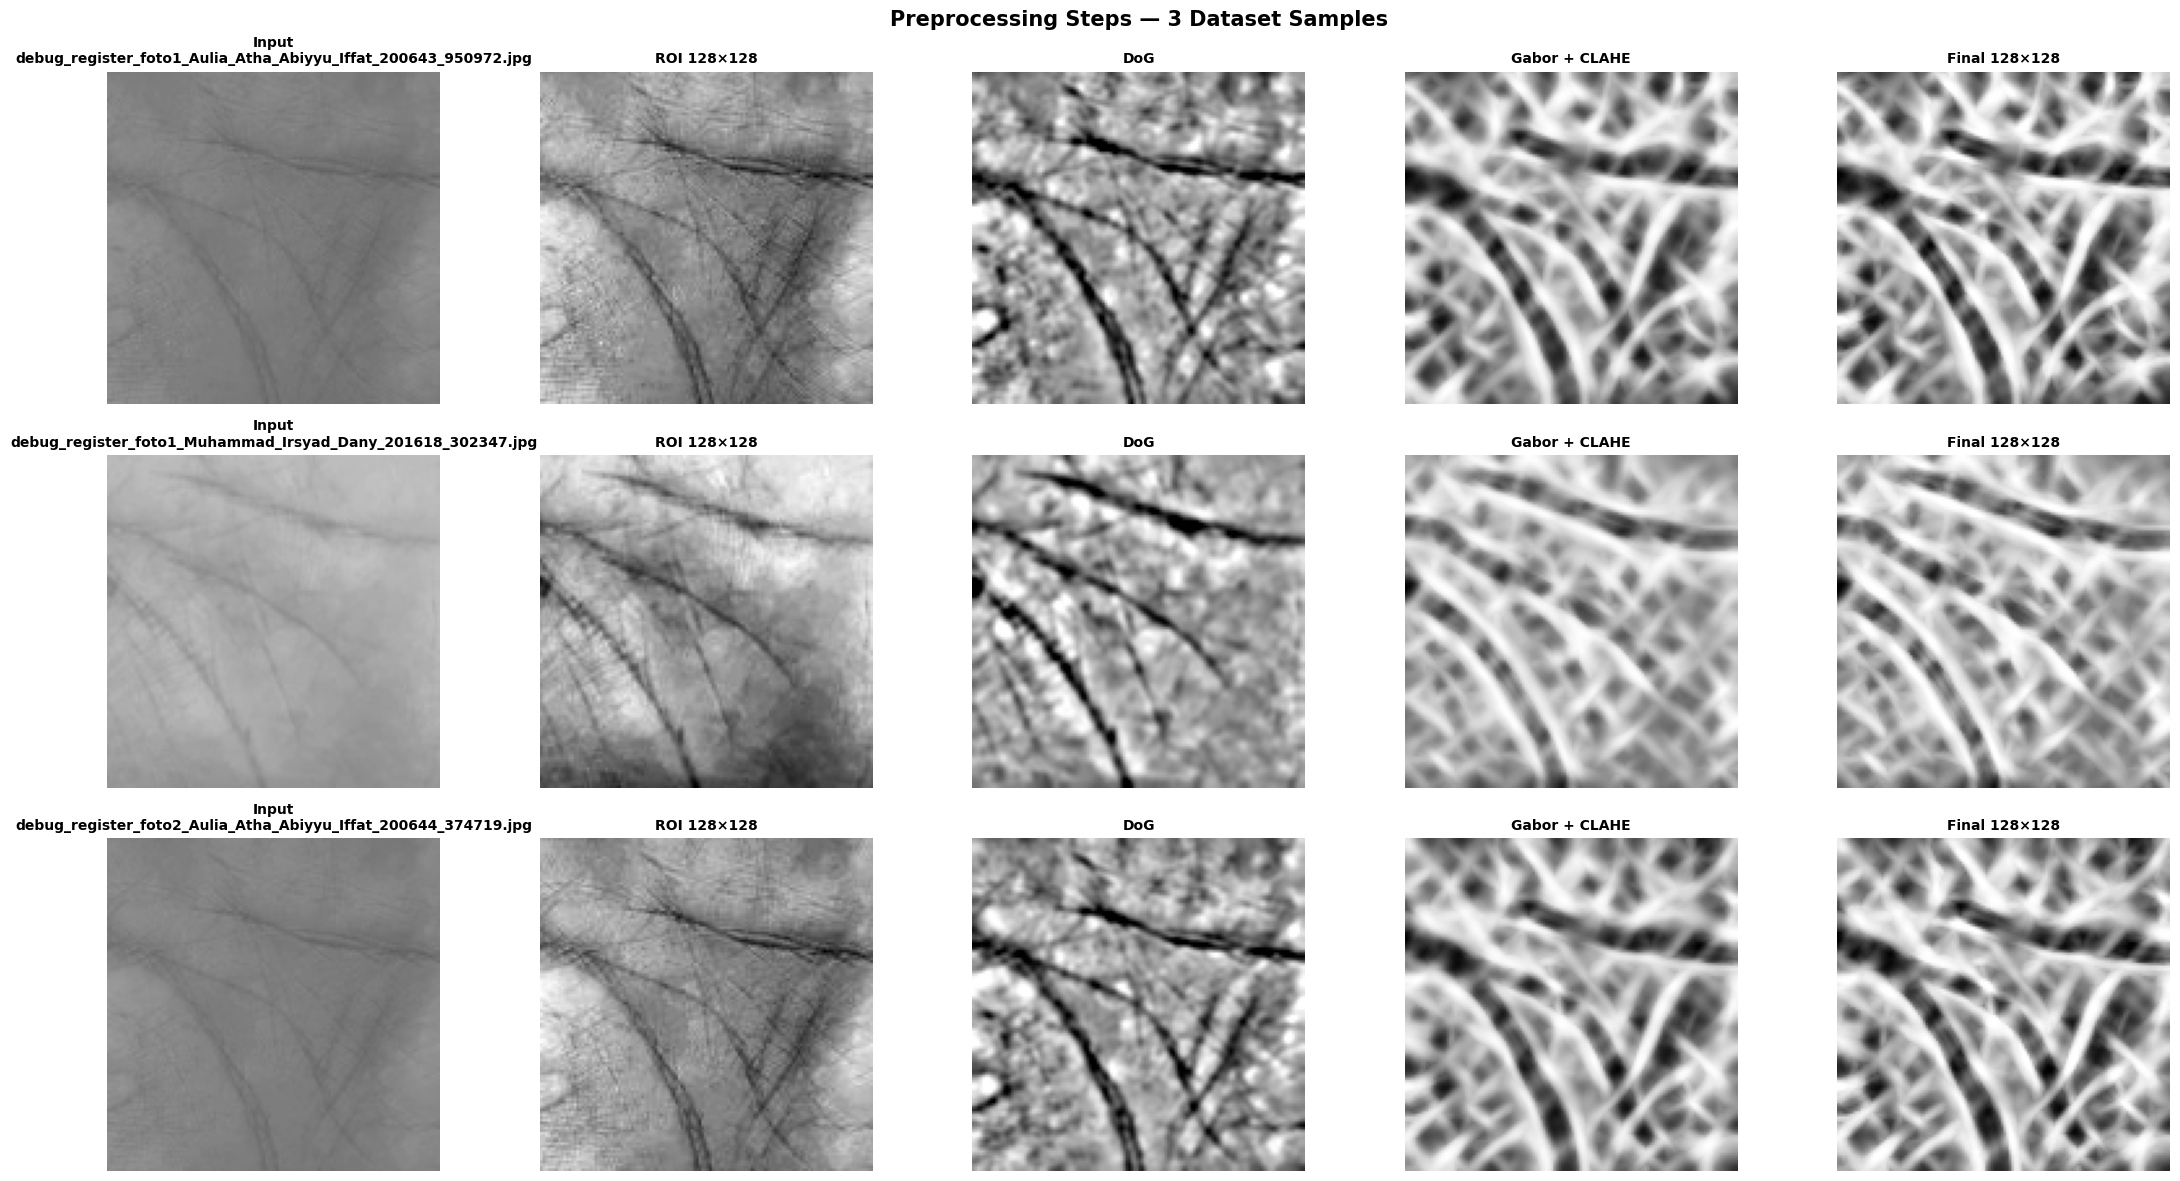

In [74]:
def normalize_illumination(img_gray, sigma_small=1.0, sigma_large=5.0):
    img_f = img_gray.astype(np.float32)

    # Tidak ada denoise — langsung DoG seperti training asli
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_small)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_large)

    dog = g_small - g_large
    dog = dog - dog.mean()
    lo, hi = np.percentile(dog, [1, 99])
    dog_clipped = np.clip(dog, lo, hi)
    return cv2.normalize(dog_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_gabor(img_gray, use_dog=True):
    if use_dog:
        img_gray = normalize_illumination(img_gray)

    responses = []
    scales = [
        {"sigma": 3.5, "lambda": 12.0},  # tetap — principal lines
        {"sigma": 2.0, "lambda": 7.0},  # dari 1.2/4.0 — sedikit lebih besar
    ]
    for scale in scales:
        for theta in Config.GABOR_THETAS:
            kernel = cv2.getGaborKernel(
                ksize=(Config.GABOR_KSIZE, Config.GABOR_KSIZE),
                sigma=scale["sigma"],
                theta=theta,
                lambd=scale["lambda"],
                gamma=Config.GABOR_GAMMA,
                psi=0,
                ktype=cv2.CV_32F,
            )
            resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
            responses.append(np.abs(resp))

    gabor_max = np.max(responses, axis=0)
    gabor_mean = np.mean(responses, axis=0)
    combined = 0.4 * gabor_max + 0.6 * gabor_mean
    combined = cv2.normalize(combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


    # hapus baris medianBlur

    clahe = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(combined)


def sharpen_and_resize(img_gray):
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 2.0)
    sharpened = cv2.addWeighted(img_gray, 1.5, gaussian, -0.5, 0)  
    return cv2.resize(
        sharpened, (Config.IMAGE_SIZE, Config.IMAGE_SIZE), interpolation=cv2.INTER_CUBIC
    )


# ── Visualisasi preprocessing pada 3 sample ──
exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")
samples = sorted(
    [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
)

if len(samples) >= 3:
    num_samples = 3
    fig, axes = plt.subplots(num_samples, 5, figsize=(22, 4 * num_samples))
    fig.suptitle(
        "Preprocessing Steps — 3 Dataset Samples", fontsize=15, fontweight="bold"
    )

    for row in range(num_samples):
        img_path = os.path.join(Config.DATASET_PATH, samples[row])
        img_s = cv2.imread(img_path)

        # Step 1: Baca langsung → grayscale (foto sudah ROI)
        roi_gray = cv2.cvtColor(img_s, cv2.COLOR_BGR2GRAY)
        roi_gray = cv2.resize(
            roi_gray, (Config.ROI_SIZE, Config.ROI_SIZE), interpolation=cv2.INTER_AREA
        )

        # Step 2: DoG
        dog_s = normalize_illumination(roi_gray)

        # Step 3: Gabor + CLAHE
        gabor_dog_s = enhance_gabor(dog_s, use_dog=False)

        # Step 4: Sharpen & Resize
        roi_for_hog = sharpen_and_resize(gabor_dog_s)

        # Kolom 1 : Input Asli
        axes[row, 0].imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f"Input\n{samples[row]}", fontsize=10, fontweight="bold")
        axes[row, 0].axis("off")

        # Kolom 2 : ROI Grayscale
        axes[row, 1].imshow(roi_gray, cmap="gray")
        axes[row, 1].set_title("ROI 128×128", fontsize=10, fontweight="bold")
        axes[row, 1].axis("off")

        # Kolom 3 : DoG
        axes[row, 2].imshow(dog_s, cmap="gray")
        axes[row, 2].set_title("DoG", fontsize=10, fontweight="bold")
        axes[row, 2].axis("off")

        # Kolom 4 : Gabor + CLAHE
        axes[row, 3].imshow(gabor_dog_s, cmap="gray")
        axes[row, 3].set_title("Gabor + CLAHE", fontsize=10, fontweight="bold")
        axes[row, 3].axis("off")

        # Kolom 5 : Final HOG
        axes[row, 4].imshow(roi_for_hog, cmap="gray")
        axes[row, 4].set_title("Final 128×128", fontsize=10, fontweight="bold")
        axes[row, 4].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("Dataset berisi kurang dari 3 gambar.")

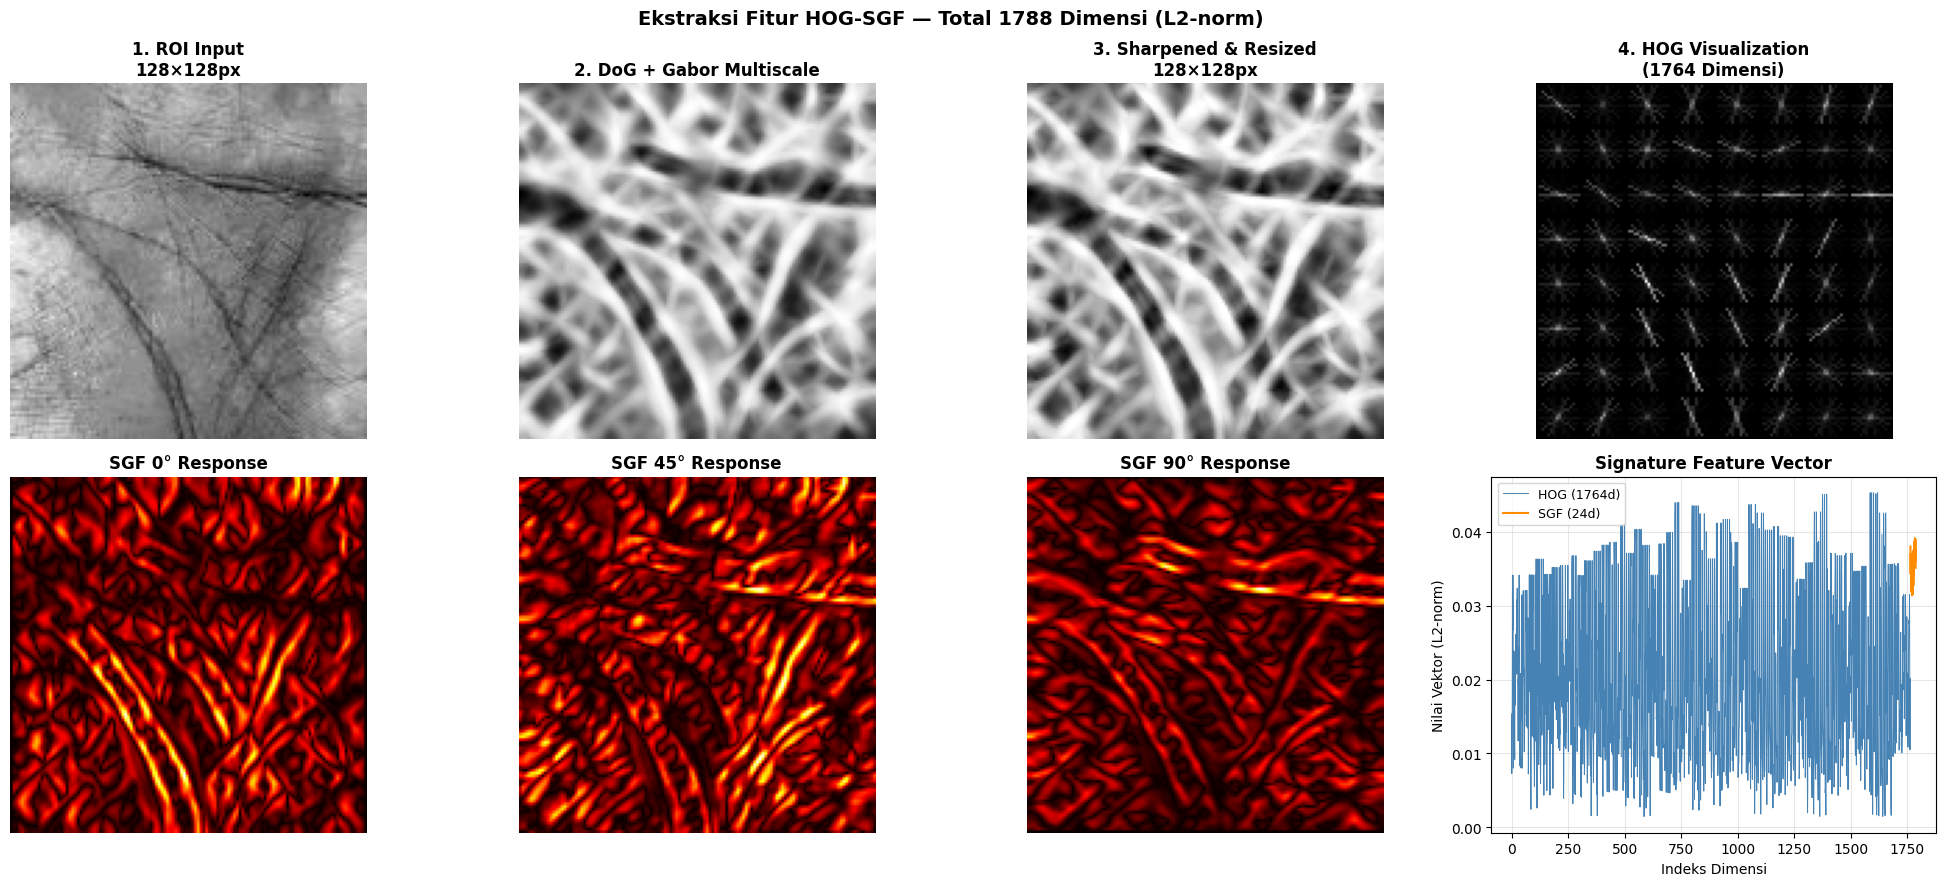

✓ Sukses! Dimensi Ekstraksi Fitur Baru: 1788 (1764d HOG + 24d SGF)


In [75]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None,
                    hog_cells=None, visualize=False):
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS

    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))

    # ── 1. HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',        # ← diubah dari 'L2'
            visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',        # ← diubah dari 'L2'
            visualize=False
        )
        hog_img = None

    # ── 2. SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    sgf_feats = []
    sgf_responses_vis = {}

    for theta in Config.SGF_ANGLES:
        FR     = np.cos(theta) * Ix + np.sin(theta) * Iy
        FR_abs = np.abs(FR)                              # ← tambahan
        sgf_feats.extend([np.mean(FR_abs), np.std(FR_abs)])  # ← pakai FR_abs

        theta_deg = int(np.degrees(theta))
        if visualize and theta_deg in [0, 45, 90]:
            sgf_responses_vis[theta_deg] = FR_abs.copy()    # ← simpan FR_abs

    sgf_feat = np.array(sgf_feats, dtype=np.float32)

    # ── 3. KOMBINASI & L2-NORMALIZATION ──
    hog_norm = hog_feat / np.maximum(np.linalg.norm(hog_feat), 1e-8)
    sgf_norm = sgf_feat / np.maximum(np.linalg.norm(sgf_feat), 1e-8)
    combined = np.concatenate([hog_norm * Config.HOG_SGF_WEIGHT,
                                sgf_norm * (1 - Config.HOG_SGF_WEIGHT)])
    total_norm = np.linalg.norm(combined)
    if total_norm > 0:
        combined = combined / total_norm

    if visualize:
        return combined, hog_img, img_64, sgf_responses_vis
    return combined


# ── DEBUG: Baca langsung dari file pertama di dataset ──
exts    = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")
samples = sorted([f for f in os.listdir(Config.DATASET_PATH)
                  if f.lower().endswith(exts)])

if len(samples) > 0:
    img_s  = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    roi_s  = cv2.cvtColor(img_s, cv2.COLOR_BGR2GRAY)
    roi_s  = cv2.resize(roi_s, (Config.ROI_SIZE, Config.ROI_SIZE),
                        interpolation=cv2.INTER_AREA)

    # Pipeline preprocessing
    dog_s       = normalize_illumination(roi_s)
    enh_s       = enhance_gabor(dog_s, use_dog=False)
    sharpened_s = sharpen_and_resize(enh_s)

    feat_s, hog_img_s, img64_s, sgf_responses_s = extract_hog_sgf(sharpened_s, visualize=True)

    sgf_dim = len(Config.SGF_ANGLES) * 2
    hog_dim = len(feat_s) - sgf_dim

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'Ekstraksi Fitur HOG-SGF — Total {len(feat_s)} Dimensi (L2-norm)',
                 fontsize=14, fontweight='bold')

    # Row 0
    axes[0, 0].imshow(roi_s, cmap='gray')
    axes[0, 0].set_title(f'1. ROI Input\n{roi_s.shape[1]}×{roi_s.shape[0]}px', fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(enh_s, cmap='gray')
    axes[0, 1].set_title('2. DoG + Gabor Multiscale', fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img64_s, cmap='gray')
    axes[0, 2].set_title(f'3. Sharpened & Resized\n{Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}px', fontweight='bold')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(hog_img_s, cmap='gray')
    axes[0, 3].set_title(f'4. HOG Visualization\n({hog_dim} Dimensi)', fontweight='bold')
    axes[0, 3].axis('off')

    # Row 1: SGF responses
    vis_mapping = [(0, 'SGF 0° Response'), (45, 'SGF 45° Response'), (90, 'SGF 90° Response')]
    for col, (deg, title) in enumerate(vis_mapping):
        if deg in sgf_responses_s:
            FR_n = cv2.normalize(np.abs(sgf_responses_s[deg]), None, 0, 255,
                                 cv2.NORM_MINMAX).astype(np.uint8)
            axes[1, col].imshow(FR_n, cmap='hot')
            axes[1, col].set_title(title, fontweight='bold')
        else:
            axes[1, col].text(0.5, 0.5, f'{deg}° Not In Config',
                              ha='center', va='center', fontweight='bold')
        axes[1, col].axis('off')

    axes[1, 3].plot(feat_s[:hog_dim], lw=0.7, color='steelblue', label=f'HOG ({hog_dim}d)')
    axes[1, 3].plot(range(hog_dim, hog_dim + sgf_dim), feat_s[hog_dim:],
                    lw=1.5, color='darkorange', label=f'SGF ({sgf_dim}d)')
    axes[1, 3].set_title('Signature Feature Vector', fontweight='bold')
    axes[1, 3].legend(fontsize=9)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlabel('Indeks Dimensi')
    axes[1, 3].set_ylabel('Nilai Vektor (L2-norm)')

    plt.tight_layout()
    plt.show()
    print(f'✓ Sukses! Dimensi Ekstraksi Fitur Baru: {len(feat_s)} ({hog_dim}d HOG + {sgf_dim}d SGF)')

else:
    print("Dataset kosong, tidak ada file gambar ditemukan.")